In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available: True


In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mahima34256987","key":"286bf7e773e5c5c022af9427bed82bd3"}'}

In [ ]:
import os

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d uraninjo/augmented-alzheimer-mri-dataset
!unzip -q augmented-alzheimer-mri-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset
License(s): GNU Lesser General Public License 3.0
100% 380M/380M [00:28<00:00, 13.9MB/s]



In [ ]:
import os


train_path = '/content/AugmentedAlzheimerDataset'
test_path  = '/content/OriginalDataset'


paths_to_check = [("TRAIN (Augmented)", train_path), ("TEST (Original)", test_path)]

for label, path in paths_to_check:
    if os.path.exists(path):
        classes = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
        print(f"\n{label} path: {path}")
        print(f"{label} classes:")
        for c in classes:
            n = len(os.listdir(os.path.join(path, c)))
            print(f"  {c:<25} {n} images")
    else:
        print(f"Directory not found: {path}")


print(f"\n✓ train_path assigned: {train_path}")
print(f"✓ test_path assigned:  {test_path}")


TRAIN (Augmented) path: /content/AugmentedAlzheimerDataset
TRAIN (Augmented) classes:
  MildDemented              8960 images
  ModerateDemented          6464 images
  NonDemented               9600 images
  VeryMildDemented          8960 images

TEST (Original) path: /content/OriginalDataset
TEST (Original) classes:
  MildDemented              896 images
  ModerateDemented          64 images
  NonDemented               3200 images
  VeryMildDemented          2240 images

✓ train_path assigned: /content/AugmentedAlzheimerDataset
✓ test_path assigned:  /content/OriginalDataset


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input


train_data = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

test_data = ImageDataGenerator(preprocessing_function=preprocess_input)

train_set = train_data.flow_from_directory(
    train_path, target_size=(224, 224),
    batch_size=32, class_mode='categorical', shuffle=True
)

test_set = test_data.flow_from_directory(
    test_path, target_size=(224, 224),
    batch_size=32, class_mode='categorical', shuffle=False
)

print("✓ Classes:", train_set.class_indices)
print("✓ Train batches:", len(train_set), "| Test batches:", len(test_set))

Found 33984 images belonging to 4 classes.
Found 6400 images belonging to 4 classes.
✓ Classes: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}
✓ Train batches: 1062 | Test batches: 200


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
base_model = ResNet50(
    input_shape=(224, 224, 3),
    weights='imagenet',
    include_top=False
)
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f"✓ Model built — trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
✓ Model built — trainable params: 562,052


In [ ]:
callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

history1 = model.fit(
    train_set,
    validation_data=test_set,
    epochs=15,
    callbacks=callbacks_p1
)
print(f"\n✓ Phase 1 best val accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

Epoch 1/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 473s 431ms/step - accuracy: 0.5451 - loss: 1.0308 - val_accuracy: 0.5930 - val_loss: 0.8114 - learning_rate: 0.0010
Epoch 2/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 459s 433ms/step - accuracy: 0.6249 - loss: 0.8150 - val_accuracy: 0.5759 - val_loss: 0.8611 - learning_rate: 0.0010
Epoch 3/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 455s 428ms/step - accuracy: 0.6504 - loss: 0.7639 - val_accuracy: 0.6364 - val_loss: 0.7376 - learning_rate: 0.0010
Epoch 4/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 452s 426ms/step - accuracy: 0.6737 - loss: 0.7205 - val_accuracy: 0.6469 - val_loss: 0.7314 - learning_rate: 0.0010
Epoch 5/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 451s 424ms/step - accuracy: 0.6855 - loss: 0.6993 - val_accuracy: 0.6798 - val_loss: 0.6995 - learning_rate: 0.0010
Epoch 6/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 446s 420ms/step - accuracy: 0.6964 - loss: 0.6744 - val_accuracy: 0.6886 - val_loss: 0.6782 - learning_rate: 0.0010
Epoch 7/15
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 442s 416ms

In [ ]:
from google.colab import drive
import shutil
import os

# 1. Connect to your Google Drive
drive.mount('/content/drive')

# 2. Copy the temporary file to your permanent Drive
if os.path.exists('/content/best_model.h5'):
    shutil.copy('/content/best_model.h5', '/content/drive/MyDrive/alzheimer_best_model.h5')
    print("✅ SUCCESS: Your model is safely backed up to Google Drive!")
else:
    print("❌ File not found. Did Epoch 1 finish completely?")

Mounted at /content/drive
✅ SUCCESS: Your model is safely backed up to Google Drive!


In [ ]:

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/best_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1)
]

history2 = model.fit(
    train_set,
    validation_data=test_set,
    epochs=30,
    callbacks=callbacks_p2
)
print(f"\n✓ Phase 2 best val accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")


Epoch 1/30
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7391 - loss: 0.6210
Epoch 1: val_accuracy improved from None to 0.75359, saving model to /content/best_model.h5



Epoch 1: finished saving model to /content/best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 497s 446ms/step - accuracy: 0.7609 - loss: 0.5737 - val_accuracy: 0.7536 - val_loss: 0.5650 - learning_rate: 1.0000e-05
Epoch 2/30
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7989 - loss: 0.4801
Epoch 2: val_accuracy improved from 0.75359 to 0.77781, saving model to /content/best_model.h5



Epoch 2: finished saving model to /content/best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 469s 442ms/step - accuracy: 0.8047 - loss: 0.4674 - val_accuracy: 0.7778 - val_loss: 0.5057 - learning_rate: 1.0000e-05
Epoch 3/30
 837/1062 ━━━━━━━━━━━━━━━━━━━━ 1:37 432ms/step - accuracy: 0.8159 - loss: 0.4277

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf


model = load_model('/content/drive/MyDrive/alzheimer_best_model.h5')
print("✓ Rescued model loaded.")


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Use your Phase 2 LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("✓ Model re-compiled to fix Optimizer variables.")


callbacks_p2_safe = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),

    ModelCheckpoint('/content/drive/MyDrive/alzheimer_best_model.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1),

    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1)
]


print("▶ Starting safe Phase 2 training...")
history2 = model.fit(
    train_set,
    validation_data=test_set,
    epochs=28,
    callbacks=callbacks_p2_safe
)

✓ Rescued model loaded.
✓ Model re-compiled to fix Optimizer variables.
▶ Starting safe Phase 2 training...
Epoch 1/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.8179 - loss: 0.4326
Epoch 1: val_accuracy improved from None to 0.77469, saving model to /content/drive/MyDrive/alzheimer_best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/alzheimer_best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 527s 476ms/step - accuracy: 0.8241 - loss: 0.4214 - val_accuracy: 0.7747 - val_loss: 0.4919 - learning_rate: 1.0000e-05
Epoch 2/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.8387 - loss: 0.3850
Epoch 2: val_accuracy improved from 0.77469 to 0.83844, saving model to /content/drive/MyDrive/alzheimer_best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/alzheimer_best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 512s 482ms/step - accuracy: 0.8417 - loss: 0.3773 - val_accuracy: 0.8384 - val_loss: 0.3833 - learning_rate: 1.0000e-05
Epoch 3/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.8539 - loss: 0.3503
Epoch 3: val_accuracy improved from 0.83844 to 0.85625, saving model to /content/drive/MyDrive/alzheimer_best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/alzheimer_best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 507s 477ms/step - accuracy: 0.8591 - loss: 0.3427 - val_accuracy: 0.8562 - val_loss: 0.3552 - learning_rate: 1.0000e-05
Epoch 4/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8725 - loss: 0.3157
Epoch 4: val_accuracy improved from 0.85625 to 0.86500, saving model to /content/drive/MyDrive/alzheimer_best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/alzheimer_best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 504s 475ms/step - accuracy: 0.8737 - loss: 0.3090 - val_accuracy: 0.8650 - val_loss: 0.3315 - learning_rate: 1.0000e-05
Epoch 5/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.8803 - loss: 0.2949
Epoch 5: val_accuracy did not improve from 0.86500
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 506s 476ms/step - accuracy: 0.8850 - loss: 0.2867 - val_accuracy: 0.8550 - val_loss: 0.3490 - learning_rate: 1.0000e-05
Epoch 6/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8924 - loss: 0.2635
Epoch 6: val_accuracy improved from 0.86500 to 0.87906, saving model to /content/drive/MyDrive/alzheimer_best_model.h5


...


Epoch 19: finished saving model to /content/drive/MyDrive/alzheimer_best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 509s 475ms/step - accuracy: 0.9630 - loss: 0.1027 - val_accuracy: 0.9516 - val_loss: 0.1407 - learning_rate: 1.0000e-05
Epoch 20/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9662 - loss: 0.0947
Epoch 20: val_accuracy improved from 0.95156 to 0.95609, saving model to /content/drive/MyDrive/alzheimer_best_model.h5



Epoch 20: finished saving model to /content/drive/MyDrive/alzheimer_best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 500s 471ms/step - accuracy: 0.9656 - loss: 0.0987 - val_accuracy: 0.9561 - val_loss: 0.1330 - learning_rate: 1.0000e-05
Epoch 21/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9654 - loss: 0.0960
Epoch 21: val_accuracy did not improve from 0.95609
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 497s 466ms/step - accuracy: 0.9655 - loss: 0.0952 - val_accuracy: 0.9356 - val_loss: 0.1948 - learning_rate: 1.0000e-05
Epoch 22/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9695 - loss: 0.0884
Epoch 22: val_accuracy did not improve from 0.95609
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 491s 463ms/step - accuracy: 0.9690 - loss: 0.0898 - val_accuracy: 0.9400 - val_loss: 0.1819 - learning_rate: 1.0000e-05
Epoch 23/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9703 - loss: 0.0849
Epoch 23: val_accuracy did not improve from 0.95609
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 485s


Epoch 25: finished saving model to /content/drive/MyDrive/alzheimer_best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 497s 468ms/step - accuracy: 0.9765 - loss: 0.0696 - val_accuracy: 0.9630 - val_loss: 0.1099 - learning_rate: 5.0000e-06
Epoch 26/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9793 - loss: 0.0603
Epoch 26: val_accuracy did not improve from 0.96297
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 496s 467ms/step - accuracy: 0.9795 - loss: 0.0605 - val_accuracy: 0.9516 - val_loss: 0.1498 - learning_rate: 5.0000e-06
Epoch 27/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9793 - loss: 0.0604
Epoch 27: val_accuracy improved from 0.96297 to 0.97250, saving model to /content/drive/MyDrive/alzheimer_best_model.h5



Epoch 27: finished saving model to /content/drive/MyDrive/alzheimer_best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 500s 471ms/step - accuracy: 0.9786 - loss: 0.0611 - val_accuracy: 0.9725 - val_loss: 0.0836 - learning_rate: 5.0000e-06
Epoch 28/28
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9808 - loss: 0.0592
Epoch 28: val_accuracy improved from 0.97250 to 0.97625, saving model to /content/drive/MyDrive/alzheimer_best_model.h5



Epoch 28: finished saving model to /content/drive/MyDrive/alzheimer_best_model.h5
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 514s 483ms/step - accuracy: 0.9802 - loss: 0.0606 - val_accuracy: 0.9762 - val_loss: 0.0658 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 28.


200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.9762 - loss: 0.0658

✓ Final Test Accuracy : 97.62%
✓ Final Test Loss     : 0.0658


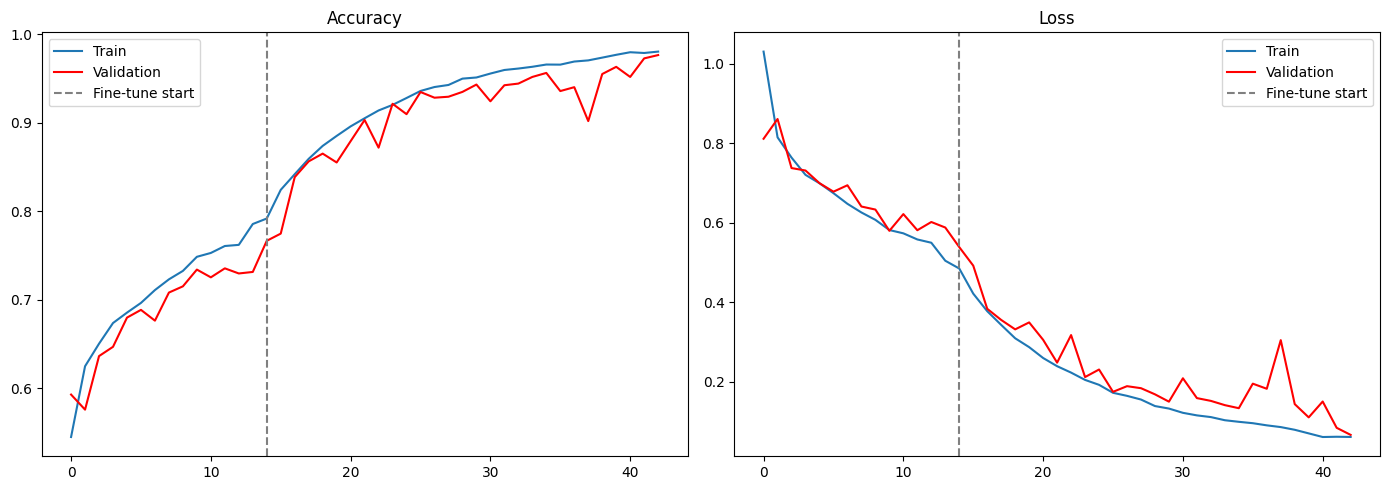

In [ ]:
test_loss, test_acc = model.evaluate(test_set, verbose=1)
print(f"\n✓ Final Test Accuracy : {test_acc*100:.2f}%")
print(f"✓ Final Test Loss     : {test_loss:.4f}")

acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
split    = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(acc,     label='Train')
ax1.plot(val_acc, label='Validation', c='red')
ax1.axvline(split-1, color='gray', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.legend()

ax2.plot(loss,     label='Train')
ax2.plot(val_loss, label='Validation', c='red')
ax2.axvline(split-1, color='gray', linestyle='--', label='Fine-tune start')
ax2.set_title('Loss'); ax2.legend()

plt.tight_layout(); plt.show()

200/200 ━━━━━━━━━━━━━━━━━━━━ 29s 105ms/step


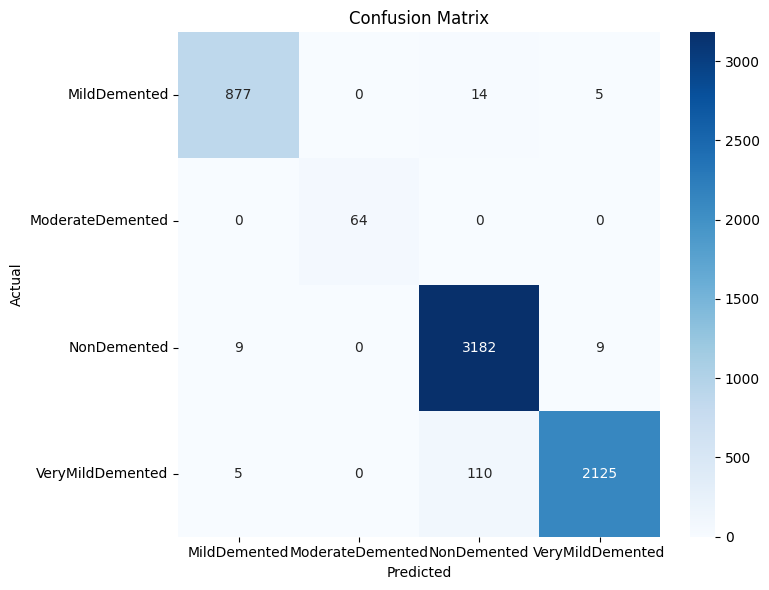

                  precision    recall  f1-score   support

    MildDemented       0.98      0.98      0.98       896
ModerateDemented       1.00      1.00      1.00        64
     NonDemented       0.96      0.99      0.98      3200
VeryMildDemented       0.99      0.95      0.97      2240

        accuracy                           0.98      6400
       macro avg       0.99      0.98      0.98      6400
    weighted avg       0.98      0.98      0.98      6400



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_set.reset()
y_pred         = model.predict(test_set, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true         = test_set.classes
class_names    = list(test_set.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()
print(classification_report(y_true, y_pred_classes, target_names=class_names))

Using image: /content/OriginalDataset/MildDemented/mildDem92.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

Prediction : MildDemented
Confidence : 100.0%
Actual     : MildDemented

All probabilities:
  MildDemented           100.0%
  ModerateDemented       0.0%
  NonDemented            0.0%
  VeryMildDemented       0.0%


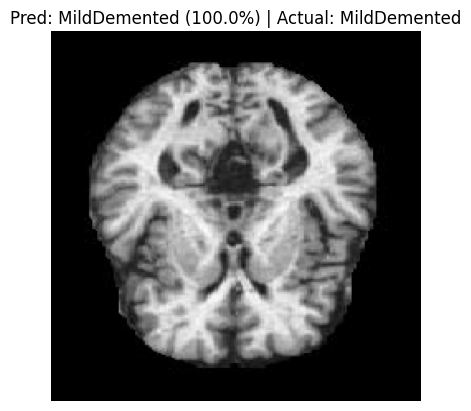

In [ ]:
out = {0:"MildDemented", 1:"ModerateDemented", 2:"NonDemented", 3:"VeryMildDemented"}


sample_class = sorted(os.listdir(test_path))[0]
sample_dir   = os.path.join(test_path, sample_class)
sample_img   = os.path.join(sample_dir, os.listdir(sample_dir)[0])
print(f"Using image: {sample_img}")


img  = load_img(sample_img, target_size=(224, 224))
arr  = img_to_array(img)
inp  = preprocess_input(np.array([arr]))

pred_probs = model.predict(inp)[0]
pred_class = np.argmax(pred_probs)
confidence = pred_probs[pred_class] * 100

print(f"\nPrediction : {out[pred_class]}")
print(f"Confidence : {confidence:.1f}%")
print(f"Actual     : {sample_class}")
print("\nAll probabilities:")
for i, p in enumerate(pred_probs):
    print(f"  {out[i]:<22} {p*100:.1f}%")

plt.imshow(img)
plt.title(f"Pred: {out[pred_class]} ({confidence:.1f}%) | Actual: {sample_class}")
plt.axis('off'); plt.show()